# ftir_46 — the paired increment test ftir_43 lacked, and the mass lead

## tl;dr

**Part 1 — paired, the spectra increment ftir_43 called "real" is not significant on its
own, and becomes so once gravimetric mass is in the base.** On the 239-filter Addis set
and ftir_43's eight time blocks, the stacked spectra rung beats the metadata base
(f(X) + season + volume + lot) by ΔRMSE **−0.060 µg/m³** (0.658 → 0.599), but the
per-filter block-bootstrap 95% CI is **[−0.134, +0.020]**, 5/8 folds, sign-test p = 0.73
— it does beat the proportional-disagreement null (0/200 draws, p = 0.005), so it is not
nothing, but it is not a paired result either. Mass as a plain covariate buys
**−0.036** [−0.099, +0.022]. Put mass in the base and the spectra increment doubles and
its interval clears zero: **−0.126 [−0.199, −0.032]**, 7/8 folds, residual R² 0.242 →
**0.517**, HIPS-prediction RMSE **0.497** against 0.658 for the base and 0.621 for
ftir_43's spectra-only learner. Forward-chained (179 filters) the same pattern holds:
(d)−(c) −0.046 [−0.128, +0.034]; (d+)−(c+) **−0.137 [−0.229, −0.044]**. At fixed f(X)
and season the residual falls with mass, **−0.068 µg/m³ per µg/m³** [−0.097, −0.045]
(× IQR = −0.77 µg/m³); the raw slope is −0.001 because mass and f(X) correlate at 0.84,
so the plain scatter hides it.

**Part 2 — the mass term replicates in sign at every site but Pasadena, and the two
Ethiopian sites carry 2–3× the rest.** Fabs ~ f(X) + mass with the locked 800 + AIRSpec
calibration: mass adds **0.68 [0.46, 0.96]** Mm⁻¹ per µg/m³ at Addis (n = 239) and
**0.68 [0.22, 1.08]** at Bishoftu (n = 26), against **0.20 [0.13, 0.27]** at Beijing
(192), 0.10 [0.10, 0.40] at Delhi (152; **0.31 [0.20, 0.48]** inside the Addis loading
range), and **0.06 [−0.06, 0.20]** at Pasadena (158). Per deposit — µg of HIPS-EC-
equivalent per µg of mass, the unit a scattering artifact lives in — Addis **0.064
[0.037, 0.091]**, Bishoftu 0.071 [0.022, 0.116], Beijing 0.019 [0.013, 0.027], Delhi
0.010 [0.009, 0.030], Pasadena 0.006 [−0.006, 0.021]; the four non-Ethiopian sites
pooled and restricted to Addis's deposit range give **0.033 [0.024, 0.044]**. The
winner-440 k = 8 calibration gives the same ordering (Addis 0.042, Beijing 0.024,
pooled non-Addis in range 0.036). **Reading: neither pure story survives.** A mass term
at fixed FTIR EC exists off-Ethiopia (Beijing's interval excludes zero; pooled 0.033),
so roughly half of the Addis coefficient is loading-shaped and generic — instrument
side. The Ethiopian excess above that floor (≈0.03–0.04 µg EC-eq per µg mass, ≈0.3–0.4
Mm⁻¹ per µg/m³, the same at two sites 45 km apart, absent at Pasadena on the same filter
lot 251) is not the instrument and is the aerosol-side lead. It would be falsified by a
HIPS loading experiment on non-absorbing deposits that returns ≥ 0.06 µg EC-eq per µg
(then it is all instrument), or by the Addis coefficient failing to track composition
(dust / OM fraction, PMF class) within Addis (then it is not aerosol).

## Context & Methods

ftir_43 scored a metadata model and a spectra learner on the same eight time blocks and
read the gap between them (residual R² 0.184 → 0.244) as "real but small". It never
tested that gap as a *paired* quantity: same folds, per-fold differences, an interval.
ftir_45 then asked what the increment is made of (season, char class, bands) and found
nothing named. This notebook does two things that were missing.

**Part 1 — the paired ladder (Addis, n = 239).** Every rung is scored on the identical
eight contiguous time blocks of ftir_43, then again forward-chained (train on blocks
0..h−1, test on block h, h ≥ 2). The rungs:

| rung | inputs | reading |
|---|---|---|
| a | training-fold mean of r | constant-bias correction |
| b | f(X) | proportional disagreement |
| c0 | f(X) + season + volume | ftir_43 M2 |
| c | c0 + filter lot | the metadata base |
| c+L / c+C | c + gravimetric mass (µg/filter / µg/m³) | the mass lead |
| d | c + AIRSpec spectra (stacked PLS on the base residual, inner time-blocked k ≤ 10) | the paired spectra increment |
| d+L / d+C | c+ + spectra | spectra increment once mass is in |
| e | spectra only (ftir_43 M3) | the residual learner as originally run |

The paired quantities are per-fold ΔRMSE and pooled ΔRMSE/ΔR² for (d)−(c), (d+)−(c+),
(c+)−(c), (e)−(c). Intervals come two ways: a bootstrap over the eight per-fold
differences, and a per-filter block bootstrap (resample whole blocks, recompute pooled
RMSE) — the second respects the time-series dependence the first ignores. Each
increment is also put against ftir_43's proportional-disagreement null
(b\* = a·f(X) + c + ε, spectra and mass untouched), 200 draws, p = (b+1)/(n+1).

**Part 2 — does the mass relationship replicate across sites?** With f(X) fixed, the
residual r = f(X) − Fabs/10 is regressed on gravimetric mass at Addis, Bishoftu, Beijing,
Delhi and Pasadena, for two calibrations pulled from the live calibration explorer:
the locked lowest-OC/EC 800 + AIRSpec (site-held-out, rule k) and the dense-sweep
winner lowest-OC/EC 440 + AIRSpec k = 8. The discriminating quantity is the mass
coefficient in Fabs ~ f(X) + mass, in Mm⁻¹ per µg/m³ (and per µg/cm² of deposit,
because a scattering artifact is per-deposit, not per-volume). If it is the same sign
and size at fixed f(X) everywhere, mass is adding apparent absorption on the HIPS side
(deposit scattering / loading) — instrument. If it is Addis-only, the extra absorption
rides with an Addis aerosol component that the FTIR-EC model does not see — aerosol.

### Key assumptions

- Part 1 uses the committed ftir_13 prediction as f(X), b = Fabs/10, r = f(X) − b, the
  239 dated Addis filters, and the same `qcut` eight-block time split as ftir_43/45.
- Gravimetric mass is `MassCollectedOnFilter_ug` from the ETAD metadata (Addis) and
  `MassCollectedOnFilter` from the per-site SPARTAN filter catalogs (other sites); mass
  concentration = mass / sample volume; mass per area = mass / HIPS DepositArea.
- Mass is a pre-analysis deposit property, not an optical quantity, so it is *not* the
  τ-circularity trap of ftir_43; but it correlates with EC, so only the partial slope at
  fixed f(X) is read.
- PLS components for the spectra rungs are chosen by inner time-blocked CV on the
  training blocks only (k ≤ 10); the stacked rungs fit PLS on the base model's residual.
- Part 2 predictions come from the explorer's `/api/run` (same call and config keys as
  `run_locked_reconstruction_confirmation.py`); the notebook caches them so a rerun
  without the server reuses the same numbers, and says so.

In [1]:
%matplotlib inline
import json
import os
import sys
import warnings
from math import comb
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression

from phase3_common import load_addis_evaluation, PATHS
from pls_transfer import predict_pls_components
from config import ETHIOPIA_SEASONS, season_for_month
from plotting import apply_default_style

warnings.filterwarnings('ignore')
apply_default_style()
OUT = Path('output/tables/ftir46')
PLOTS = Path('output/plots/ftir46')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MAC, N_BLOCKS, MAX_K = 10.0, 8, 10
N_BOOT, N_NULL = 5000, 200
RNG = np.random.default_rng(20260901)
EXPLORER = os.environ.get('FTIR46_EXPLORER_URL', 'http://127.0.0.1:5058')
TARGETS_DIR = Path('../../calibration_explorer/targets')
CATALOG_DIR = Path('/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/'
                   'University/Research/Grad/Data/Davis Data/DAVIS/SPARTAN FTIR pulls')
SEASON_COLORS = {name: spec['color'] for name, spec in ETHIOPIA_SEASONS.items()}

## Data (Part 1)

The ftir_43 construction, plus two pre-analysis filter properties: the manufacturing
lot (HIPS `LotId`) and the gravimetric mass on the filter.

In [2]:
etad_eval, _X_raw, _wn = load_addis_evaluation()
committed = pd.read_csv('output/tables/ftir13/addis_predictions_corrected.csv')
frame = etad_eval.merge(
    committed[['MediaId', 'lowest-OCEC 800, AIRSpec df1=6']].rename(
        columns={'lowest-OCEC 800, AIRSpec df1=6': 'f_x'}),
    on='MediaId', how='inner', validate='one_to_one')
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
corr_by_media = etad_corr.groupby('MediaId').mean()

n_all = len(frame)
frame = frame[frame['SamplingStartDate'].notna()].sort_values('SamplingStartDate').reset_index(drop=True)
hips_lots = pd.read_csv(PATHS.spartan_hips_primary, encoding='cp1252',
                        usecols=['Site', 'FilterId', 'LotId', 'DepositArea'])
lot_by_filter = (hips_lots[hips_lots['Site'].eq('ETAD')].dropna(subset=['LotId'])
                 .drop_duplicates('FilterId').set_index('FilterId')['LotId'])
frame['lot'] = frame['ExternalFilterId'].map(lot_by_filter).fillna(-1).astype(int)

X = corr_by_media.loc[frame['MediaId'].astype(int)].to_numpy(float)
f_x = frame['f_x'].to_numpy(float)
b = frame['Fabs'].to_numpy(float) / MAC
r = f_x - b
n = len(r)
block = np.asarray(pd.qcut(np.arange(n), N_BLOCKS, labels=False))
month = frame['SamplingStartDate'].dt.month.to_numpy()
season_name = np.array([season_for_month(int(m)) for m in month])
season_cols = np.column_stack([np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12)])
volume = frame['SampleVolume_m3'].to_numpy(float)
mass_ug = frame['MassCollectedOnFilter_ug'].to_numpy(float)
mass_conc = mass_ug / volume
deposit_area = frame['DepositArea'].fillna(3.53).to_numpy(float)
mass_area = mass_ug / deposit_area
lot = frame['lot'].to_numpy()
lot_cols = np.column_stack([(lot == L).astype(float) for L in sorted(set(lot))])
print(f'evaluation filters with a committed prediction: {n_all}; dated (time-blockable): {n}; '
      f'mass present for {int(np.isfinite(mass_ug).sum())}; lots {dict(pd.Series(lot).value_counts().sort_index())}')
print(f'mass on filter {np.median(mass_ug):.0f} µg median (range {mass_ug.min():.0f}–{mass_ug.max():.0f}); '
      f'concentration {np.median(mass_conc):.1f} µg/m³ median; deposit area {np.unique(deposit_area)} cm²')
print(f'corr(mass_conc, f(X)) = {np.corrcoef(mass_conc, f_x)[0, 1]:.3f}; '
      f'corr(mass_conc, Fabs/10) = {np.corrcoef(mass_conc, b)[0, 1]:.3f}; '
      f'corr(mass_conc, r) = {np.corrcoef(mass_conc, r)[0, 1]:.3f}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
evaluation filters with a committed prediction: 239; dated (time-blockable): 239; mass present for 239; lots {248: np.int64(34), 251: np.int64(191), 253: np.int64(14)}
mass on filter 146 µg median (range 57–378); concentration 20.8 µg/m³ median; deposit area [3.53] cm²
corr(mass_conc, f(X)) = 0.839; corr(mass_conc, Fabs/10) = 0.833; corr(mass_conc, r) = -0.008


## Results

### 1. The paired ladder — blocked and forward-chained

Ten models, one out-of-fold prediction vector each per scheme. Stacked rungs (d, d+)
refit the base linear model inside every inner fold and let PLS model its residual, so
the spectra can only add what the base does not already explain.

In [3]:
BASE_C0 = np.column_stack([f_x, season_cols, volume])
BASE_C = np.column_stack([BASE_C0, lot_cols])
DESIGNS = {
    'b': f_x.reshape(-1, 1),
    'c0': BASE_C0,
    'c': BASE_C,
    'c+L': np.column_stack([BASE_C, mass_ug]),
    'c+C': np.column_stack([BASE_C, mass_conc]),
}


def const_pred(tr, te, y, klog=None):
    return np.full(int(te.sum()), y[tr].mean())


def lin_pred(design):
    def p(tr, te, y, klog=None):
        return LinearRegression().fit(design[tr], y[tr]).predict(design[te])
    return p


def pls_choose_k(Xtr, ytr, groups, ks, base_design=None):
    """Inner time-blocked CV over the training blocks (ftir_43 rule). With a base
    design, the linear base is refit inside each inner fold and PLS models its residual."""
    sse = np.zeros(len(ks))
    for g in np.unique(groups):
        itr, ite = groups != g, groups == g
        if itr.sum() <= MAX_K or ite.sum() == 0:
            continue
        y_itr, y_ite = ytr[itr], ytr[ite]
        if base_design is not None:
            lm = LinearRegression().fit(base_design[itr], y_itr)
            base_tr, base_te = lm.predict(base_design[itr]), lm.predict(base_design[ite])
        else:
            base_tr, base_te = 0.0, 0.0
        m = PLSRegression(n_components=max(ks), scale=False).fit(Xtr[itr], y_itr - base_tr)
        preds = predict_pls_components(m, Xtr[ite], np.asarray(ks))   # (n_test, len(ks))
        base_te_col = base_te[:, None] if np.ndim(base_te) else base_te
        sse += ((base_te_col + preds - y_ite[:, None]) ** 2).sum(axis=0)
    return int(ks[np.argmin(sse)])


KS = np.arange(1, MAX_K + 1)


def pls_pred(tr, te, y, klog=None):
    k = pls_choose_k(X[tr], y[tr], block[tr], KS)
    if klog is not None:
        klog.append(k)
    return PLSRegression(n_components=k, scale=False).fit(X[tr], y[tr]).predict(X[te]).ravel()


def stacked_pred(design):
    def p(tr, te, y, klog=None):
        k = pls_choose_k(X[tr], y[tr], block[tr], KS, base_design=design[tr])
        if klog is not None:
            klog.append(k)
        lm = LinearRegression().fit(design[tr], y[tr])
        m = PLSRegression(n_components=k, scale=False).fit(X[tr], y[tr] - lm.predict(design[tr]))
        return lm.predict(design[te]) + m.predict(X[te]).ravel()
    return p


MODELS = {
    'a  constant': const_pred,
    'b  f(X)': lin_pred(DESIGNS['b']),
    'c0 f(X)+season+volume (ftir_43 M2)': lin_pred(DESIGNS['c0']),
    'c  c0+lot': lin_pred(DESIGNS['c']),
    'c+L c+mass µg/filter': lin_pred(DESIGNS['c+L']),
    'c+C c+mass µg/m³': lin_pred(DESIGNS['c+C']),
    'd  c+spectra (stacked)': stacked_pred(DESIGNS['c']),
    'd+L c+L+spectra (stacked)': stacked_pred(DESIGNS['c+L']),
    'd+C c+C+spectra (stacked)': stacked_pred(DESIGNS['c+C']),
    'e  spectra only (ftir_43 M3)': pls_pred,
}


def splits(scheme):
    if scheme == 'blocked':
        for h in range(N_BLOCKS):
            yield h, block != h, block == h
    else:  # forward-chained: at least two training blocks for the inner CV
        for h in range(2, N_BLOCKS):
            yield h, block < h, block == h


def run_scheme(scheme, y=r, models=MODELS):
    oof, klogs, rows = {}, {}, []
    for name, pred in models.items():
        yhat, klog = np.full(n, np.nan), []
        for h, tr, te in splits(scheme):
            yhat[te] = pred(tr, te, y, klog=klog)
        oof[name], klogs[name] = yhat, klog
        for h, tr, te in splits(scheme):
            e = yhat[te] - y[te]
            rows.append(dict(scheme=scheme, model=name, fold=h, n_test=int(te.sum()),
                             rmse=float(np.sqrt((e ** 2).mean())),
                             r2_fold=float(1 - (e ** 2).sum() / ((y[te] - y[te].mean()) ** 2).sum())))
    per_fold = pd.DataFrame(rows)
    mask = ~np.isnan(next(iter(oof.values())))
    summ = []
    for name, yhat in oof.items():
        e, yy = yhat[mask] - y[mask], y[mask]
        pf = per_fold[per_fold.model == name]
        summ.append(dict(scheme=scheme, model=name, n_scored=int(mask.sum()),
                         pooled_R2=float(1 - (e ** 2).sum() / ((yy - yy.mean()) ** 2).sum()),
                         meanfold_R2=float(pf.r2_fold.mean()),
                         pooled_RMSE=float(np.sqrt((e ** 2).mean())),
                         meanfold_RMSE=float(pf.rmse.mean()),
                         k_chosen=str(klogs[name]) if klogs[name] else ''))
    summ.append(dict(scheme=scheme, model='0  no correction', n_scored=int(mask.sum()),
                     pooled_R2=0.0, meanfold_R2=np.nan,
                     pooled_RMSE=float(np.sqrt((y[mask] ** 2).mean())), meanfold_RMSE=np.nan, k_chosen=''))
    return oof, per_fold, pd.DataFrame(summ), mask


def block_indices(scheme, mask):
    folds = [h for h, _, _ in splits(scheme)]
    return folds, {h: np.where((block == h) & mask)[0] for h in folds}


def rung_rmse_ci(oof, mask, scheme, y=r, n_boot=N_BOOT):
    """Per-filter block bootstrap of each rung's pooled RMSE (resample whole blocks)."""
    folds, idx_by_fold = block_indices(scheme, mask)
    F = len(folds)
    picks = [np.concatenate([idx_by_fold[folds[i]] for i in RNG.integers(0, F, F)]) for _ in range(n_boot)]
    rows = []
    for name, yhat in oof.items():
        e = yhat - y
        boots = np.array([np.sqrt((e[ii] ** 2).mean()) for ii in picks])
        rows.append(dict(scheme=scheme, model=name, rmse_ci_lo=float(np.quantile(boots, .025)),
                         rmse_ci_hi=float(np.quantile(boots, .975))))
    return pd.DataFrame(rows)


RESULTS = {}
for scheme in ('blocked', 'forward'):
    RESULTS[scheme] = run_scheme(scheme)
ladder = pd.concat([RESULTS[s][2] for s in RESULTS], ignore_index=True)
rung_ci = pd.concat([rung_rmse_ci(RESULTS[s][0], RESULTS[s][3], s) for s in RESULTS], ignore_index=True)
ladder = ladder.merge(rung_ci, on=['scheme', 'model'], how='left')
ladder.to_csv(OUT / 'ladder_summary.csv', index=False)
pd.concat([RESULTS[s][1] for s in RESULTS], ignore_index=True).to_csv(OUT / 'ladder_per_fold.csv', index=False)
for s in RESULTS:
    pd.DataFrame(RESULTS[s][0]).assign(y=r, block=block, MediaId=frame['MediaId'].to_numpy()).to_csv(
        OUT / f'oof_{s}.csv', index=False)
display(ladder.pivot(index='model', columns='scheme',
                     values=['pooled_R2', 'meanfold_R2', 'pooled_RMSE', 'rmse_ci_lo', 'rmse_ci_hi']).round(3))
print('components chosen per fold:')
display(ladder[ladder.k_chosen.ne('')][['scheme', 'model', 'k_chosen']])

pooled_R2         meanfold_R2          \
scheme                               blocked forward     blocked forward   
model                                                                      
0  no correction                       0.000   0.000         NaN     NaN   
a  constant                           -0.012  -0.031      -0.076  -0.103   
b  f(X)                                0.064   0.053      -0.032  -0.054   
c  c0+lot                              0.152   0.008      -0.016  -0.225   
c+C c+mass µg/m³                       0.242   0.103       0.124  -0.077   
c+L c+mass µg/filter                   0.249   0.140       0.131  -0.060   
c0 f(X)+season+volume (ftir_43 M2)     0.184   0.033       0.027  -0.146   
d  c+spectra (stacked)                 0.298   0.125       0.101  -0.067   
d+C c+C+spectra (stacked)              0.517   0.415       0.399   0.251   
d+L c+L+spectra (stacked)              0.530   0.386       0.379   0.238   
e  spectra only (ftir_43 M3)           0.244   0.148       0.051   0.025   

                                   pooled_RMSE         rmse_ci_lo          \
scheme                                 blocked forward    blocked forward   
model                                                                       
0  no correction                         2.458   2.427        NaN     NaN   
a  constant                              0.719   0.766      0.582   0.604   
b  f(X)                                  0.691   0.734      0.577   0.605   
c  c0+lot                                0.658   0.751      0.585   0.638   
c+C c+mass µg/m³                         0.622   0.714      0.530   0.606   
c+L c+mass µg/filter                     0.619   0.699      0.527   0.608   
c0 f(X)+season+volume (ftir_43 M2)       0.646   0.741      0.573   0.617   
d  c+spectra (stacked)                   0.599   0.705      0.533   0.624   
d+C c+C+spectra (stacked)                0.497   0.577      0.430   0.489   
d+L c+L+spectra (stacked)                0.490   0.591      0.435   0.483   
e  spectra only (ftir_43 M3)             0.621   0.696      0.524   0.579   

                                   rmse_ci_hi          
scheme                                blocked forward  
model                                                  
0  no correction                          NaN     NaN  
a  constant                             0.849   0.906  
b  f(X)                                 0.807   0.866  
c  c0+lot                               0.731   0.857  
c+C c+mass µg/m³                        0.719   0.848  
c+L c+mass µg/filter                    0.709   0.802  
c0 f(X)+season+volume (ftir_43 M2)      0.722   0.855  
d  c+spectra (stacked)                  0.647   0.790  
d+C c+C+spectra (stacked)               0.563   0.653  
d+L c+L+spectra (stacked)               0.542   0.684  
e  spectra only (ftir_43 M3)            0.709   0.812

components chosen per fold:


,scheme,model,k_chosen
6,blocked,d c+spectra (stacked),"[7, 6, 8, 6, 6, 10, 6, 10]"
7,blocked,d+L c+L+spectra (stacked),"[7, 6, 8, 6, 6, 9, 9, 7]"
8,blocked,d+C c+C+spectra (stacked),"[7, 6, 8, 7, 7, 9, 9, 6]"
9,blocked,e spectra only (ftir_43 M3),"[6, 6, 8, 8, 6, 10, 5, 5]"
17,forward,d c+spectra (stacked),"[1, 5, 6, 10, 5, 10]"
18,forward,d+L c+L+spectra (stacked),"[7, 8, 5, 10, 7, 7]"
19,forward,d+C c+C+spectra (stacked),"[7, 8, 5, 10, 7, 6]"
20,forward,e spectra only (ftir_43 M3),"[2, 5, 6, 9, 6, 5]"


### 2. Paired differences with intervals

Per-fold ΔRMSE (negative = the higher rung is better), a bootstrap over the folds, a
per-filter block bootstrap of the pooled ΔRMSE and ΔR², and an exact two-sided sign
test on the fold wins.

In [4]:
PAIRS = [
    ('d  c+spectra (stacked)', 'c  c0+lot', '(d)−(c): spectra beyond metadata'),
    ('d+C c+C+spectra (stacked)', 'c+C c+mass µg/m³', '(d+)−(c+): spectra beyond metadata+mass'),
    ('d+L c+L+spectra (stacked)', 'c+L c+mass µg/filter', '(d+L)−(c+L): spectra beyond metadata+mass/filter'),
    ('c+C c+mass µg/m³', 'c  c0+lot', '(c+)−(c): mass µg/m³ beyond metadata'),
    ('c+L c+mass µg/filter', 'c  c0+lot', '(c+L)−(c): mass µg/filter beyond metadata'),
    ('e  spectra only (ftir_43 M3)', 'c  c0+lot', '(e)−(c): spectra-only vs metadata'),
    ('c  c0+lot', 'c0 f(X)+season+volume (ftir_43 M2)', '(c)−(c0): lot'),
    ('c0 f(X)+season+volume (ftir_43 M2)', 'b  f(X)', '(c0)−(b): season+volume'),
    ('b  f(X)', 'a  constant', '(b)−(a): f(X) beyond a constant'),
]


def paired(scheme, y=r, n_boot=N_BOOT):
    oof, per_fold, _, mask = RESULTS[scheme]
    folds, idx_by_fold = block_indices(scheme, mask)
    F = len(folds)
    picks = [[folds[i] for i in RNG.integers(0, F, F)] for _ in range(n_boot)]
    rows = []
    for hi, lo, label in PAIRS:
        diff = (per_fold[per_fold.model == hi].set_index('fold').rmse
                - per_fold[per_fold.model == lo].set_index('fold').rmse).to_numpy()
        fold_bs = np.array([diff[RNG.integers(0, F, F)].mean() for _ in range(n_boot)])
        e_hi, e_lo = oof[hi] - y, oof[lo] - y
        bb, rr = [], []
        for pick in picks:
            ii = np.concatenate([idx_by_fold[h] for h in pick])
            yy = y[ii]
            sst = ((yy - yy.mean()) ** 2).sum()
            bb.append(np.sqrt((e_hi[ii] ** 2).mean()) - np.sqrt((e_lo[ii] ** 2).mean()))
            rr.append(((e_lo[ii] ** 2).sum() - (e_hi[ii] ** 2).sum()) / sst)
        bb, rr = np.array(bb), np.array(rr)
        wins = int((diff < 0).sum())
        p_sign = min(1.0, 2 * sum(comb(F, j) for j in range(0, min(wins, F - wins) + 1)) / 2 ** F)
        sst_all = ((y[mask] - y[mask].mean()) ** 2).sum()
        rows.append(dict(
            scheme=scheme, contrast=label, model_hi=hi, model_lo=lo, n_folds=F, folds_hi_better=wins,
            p_sign_two_sided=p_sign, mean_fold_dRMSE=float(diff.mean()),
            fold_boot_ci_lo=float(np.quantile(fold_bs, .025)), fold_boot_ci_hi=float(np.quantile(fold_bs, .975)),
            pooled_dRMSE=float(np.sqrt((e_hi[mask] ** 2).mean()) - np.sqrt((e_lo[mask] ** 2).mean())),
            block_boot_ci_lo=float(np.quantile(bb, .025)), block_boot_ci_hi=float(np.quantile(bb, .975)),
            pooled_dR2=float(((e_lo[mask] ** 2).sum() - (e_hi[mask] ** 2).sum()) / sst_all),
            dR2_block_ci_lo=float(np.quantile(rr, .025)), dR2_block_ci_hi=float(np.quantile(rr, .975)),
            per_fold_dRMSE=';'.join(f'{d:+.3f}' for d in diff)))
    return pd.DataFrame(rows)


paired_diffs = pd.concat([paired(s) for s in RESULTS], ignore_index=True)
paired_diffs.to_csv(OUT / 'paired_differences.csv', index=False)
display(paired_diffs[['scheme', 'contrast', 'folds_hi_better', 'n_folds', 'p_sign_two_sided',
                      'pooled_dRMSE', 'block_boot_ci_lo', 'block_boot_ci_hi',
                      'mean_fold_dRMSE', 'fold_boot_ci_lo', 'fold_boot_ci_hi',
                      'pooled_dR2', 'dR2_block_ci_lo', 'dR2_block_ci_hi']].round(3))

,scheme,contrast,folds_hi_better,n_folds,p_sign_two_sided,pooled_dRMSE,block_boot_ci_lo,block_boot_ci_hi,mean_fold_dRMSE,fold_boot_ci_lo,fold_boot_ci_hi,pooled_dR2,dR2_block_ci_lo,dR2_block_ci_hi
0,blocked,(d)−(c): spectra beyond metadata,5,8,0.727,-0.060,-0.134,0.020,-0.058,-0.134,0.019,0.147,-0.064,0.301
1,blocked,(d+)−(c+): spectra beyond metadata+mass,7,8,0.070,-0.126,-0.199,-0.032,-0.121,-0.201,-0.032,0.276,0.082,0.429
2,blocked,(d+L)−(c+L): spectra beyond metadata+mass/filter,7,8,0.070,-0.129,-0.220,-0.018,-0.121,-0.214,-0.018,0.280,0.049,0.455
3,blocked,(c+)−(c): mass µg/m³ beyond metadata,5,8,0.727,-0.036,-0.099,0.022,-0.041,-0.100,0.015,0.090,-0.051,0.271
4,blocked,(c+L)−(c): mass µg/filter beyond metadata,5,8,0.727,-0.039,-0.104,0.020,-0.044,-0.105,0.014,0.098,-0.048,0.287
5,blocked,(e)−(c): spectra-only vs metadata,4,8,1.000,-0.037,-0.139,0.057,-0.043,-0.144,0.057,0.092,-0.164,0.345
6,blocked,(c)−(c0): lot,4,8,1.000,0.013,-0.000,0.034,0.012,-0.000,0.034,-0.032,-0.101,0.001
7,blocked,(c0)−(b): season+volume,5,8,0.727,-0.046,-0.111,0.015,-0.035,-0.098,0.016,0.120,-0.047,0.254
8,blocked,(b)−(a): f(X) beyond a constant,5,8,0.727,-0.027,-0.063,0.012,-0.022,-0.059,0.016,0.076,-0.039,0.164
9,forward,(d)−(c): spectra beyond metadata,3,6,1.000,-0.046,-0.128,0.034,-0.039,-0.114,0.033,0.118,-0.092,0.354


### 3. The increments against the proportional-disagreement null

b\* = a·f(X) + c + ε with a, c, σ matched to the data; spectra, metadata and mass left
exactly as observed, so any increment a rung shows under the null is what a learner
gets from nothing. Blocked scheme, 200 draws.

In [5]:
ols = LinearRegression().fit(f_x.reshape(-1, 1), b)
a_hat, c_hat = float(ols.coef_[0]), float(ols.intercept_)
sigma_hat = float(np.std(b - ols.predict(f_x.reshape(-1, 1)), ddof=2))
print(f'observed: b = {a_hat:.3f}·f(X) + {c_hat:.3f} + ε, σ_ε = {sigma_hat:.3f}')

NULL_MODELS = {k: MODELS[k] for k in ('b  f(X)', 'c  c0+lot', 'c+C c+mass µg/m³',
                                      'd  c+spectra (stacked)', 'd+C c+C+spectra (stacked)',
                                      'e  spectra only (ftir_43 M3)')}
SHORT = {'b  f(X)': 'b', 'c  c0+lot': 'c', 'c+C c+mass µg/m³': 'c+', 'd  c+spectra (stacked)': 'd',
         'd+C c+C+spectra (stacked)': 'd+', 'e  spectra only (ftir_43 M3)': 'e'}


def null_stats(y):
    _, per_fold, summ, _ = run_scheme('blocked', y=y, models=NULL_MODELS)
    s = summ.set_index('model')
    fold = per_fold.pivot(index='fold', columns='model', values='rmse').rename(columns=SHORT)
    out = {f'R2_{SHORT[m]}': s.loc[m, 'pooled_R2'] for m in NULL_MODELS}
    out.update({f'RMSE_{SHORT[m]}': s.loc[m, 'pooled_RMSE'] for m in NULL_MODELS})
    for hi, lo in (('d', 'c'), ('d+', 'c+'), ('c+', 'c'), ('e', 'c')):
        out[f'dRMSE_{hi}_{lo}'] = out[f'RMSE_{hi}'] - out[f'RMSE_{lo}']
        out[f'dR2_{hi}_{lo}'] = out[f'R2_{hi}'] - out[f'R2_{lo}']
        out[f'folds_{hi}_beats_{lo}'] = int((fold[hi] < fold[lo]).sum())
    return out


observed = null_stats(r)
null_rows = []
for _ in range(N_NULL):
    b_null = a_hat * f_x + c_hat + RNG.normal(0, sigma_hat, n)
    null_rows.append(null_stats(f_x - b_null))
null = pd.DataFrame(null_rows)
null.to_csv(OUT / 'null_increment_draws.csv', index=False)

TESTS = [('R2_b', 'ge'), ('R2_c', 'ge'), ('R2_c+', 'ge'), ('R2_d', 'ge'), ('R2_d+', 'ge'), ('R2_e', 'ge'),
         ('dRMSE_d_c', 'le'), ('dR2_d_c', 'ge'), ('folds_d_beats_c', 'ge'),
         ('dRMSE_d+_c+', 'le'), ('dR2_d+_c+', 'ge'),
         ('dRMSE_c+_c', 'le'), ('dR2_c+_c', 'ge'),
         ('dRMSE_e_c', 'le'), ('dR2_e_c', 'ge')]
rows = []
for stat, direction in TESTS:
    x, o = null[stat].to_numpy(), observed[stat]
    b_count = int((x >= o).sum()) if direction == 'ge' else int((x <= o).sum())
    rows.append(dict(stat=stat, observed=o, null_median=float(np.median(x)),
                     null_q05=float(np.quantile(x, .05)), null_q95=float(np.quantile(x, .95)),
                     direction=direction, b_count=b_count, n_null=N_NULL, p_value=(b_count + 1) / (N_NULL + 1)))
null_summary = pd.DataFrame(rows)
null_summary.to_csv(OUT / 'null_increment_summary.csv', index=False)
display(null_summary.round(4))

observed: b = 0.802·f(X) + 2.851 + ε, σ_ε = 0.683


,stat,observed,null_median,null_q05,null_q95,direction,b_count,n_null,p_value
0,R2_b,0.0639,0.0786,0.0192,0.1466,ge,128,200,0.6418
1,R2_c,0.1517,0.0333,-0.0846,0.1181,ge,0,200,0.0050
2,R2_c+,0.2415,0.0312,-0.1002,0.1105,ge,0,200,0.0050
3,R2_d,0.2984,0.0153,-0.1370,0.0994,ge,0,200,0.0050
4,R2_d+,0.5172,0.0089,-0.1590,0.0957,ge,0,200,0.0050
5,R2_e,0.2440,0.0468,-0.0429,0.1149,ge,0,200,0.0050
6,dRMSE_d_c,-0.0596,0.0052,-0.0017,0.0309,le,0,200,0.0050
7,dR2_d_c,0.1466,-0.0143,-0.0940,0.0047,ge,0,200,0.0050
8,folds_d_beats_c,5.0000,3.0000,1.0000,5.0000,ge,36,200,0.1841
9,dRMSE_d+_c+,-0.1258,0.0053,-0.0019,0.0320,le,0,200,0.0050


### 4. Figure — the ladder with intervals, blocked vs forward

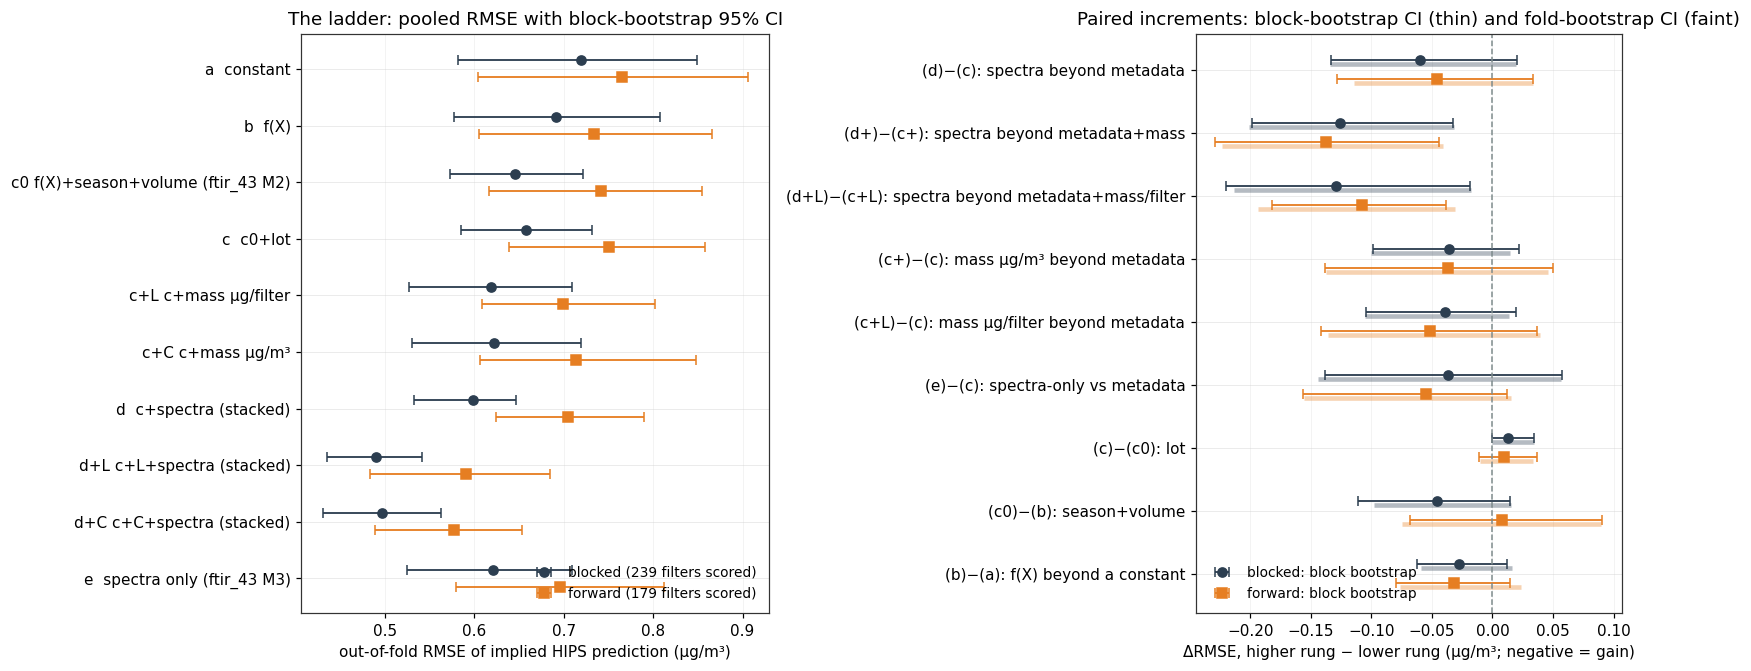

In [6]:
ORDER = list(MODELS)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={'width_ratios': [1.1, 1]})
ax = axes[0]
for j, (scheme, color, marker, off) in enumerate((('blocked', '#2C3E50', 'o', -0.15), ('forward', '#E67E22', 's', 0.15))):
    s = ladder[ladder.scheme.eq(scheme)].set_index('model').loc[ORDER]
    ys = np.arange(len(ORDER)) + off
    ax.errorbar(s.pooled_RMSE, ys, xerr=[s.pooled_RMSE - s.rmse_ci_lo, s.rmse_ci_hi - s.pooled_RMSE],
                fmt=marker, color=color, ecolor=color, capsize=3, ms=6, lw=1.2,
                label=f'{scheme} ({int(s.n_scored.iloc[0])} filters scored)')
ax.set(yticks=range(len(ORDER)), yticklabels=ORDER, xlabel='out-of-fold RMSE of implied HIPS prediction (µg/m³)',
       title='The ladder: pooled RMSE with block-bootstrap 95% CI')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc='lower right')

ax = axes[1]
labels = [p[2] for p in PAIRS]
for scheme, color, marker, off in (('blocked', '#2C3E50', 'o', -0.15), ('forward', '#E67E22', 's', 0.15)):
    s = paired_diffs[paired_diffs.scheme.eq(scheme)].set_index('contrast').loc[labels]
    ys = np.arange(len(labels)) + off
    ax.errorbar(s.pooled_dRMSE, ys, xerr=[s.pooled_dRMSE - s.block_boot_ci_lo, s.block_boot_ci_hi - s.pooled_dRMSE],
                fmt=marker, color=color, ecolor=color, capsize=3, ms=6, lw=1.2, label=f'{scheme}: block bootstrap')
    ax.errorbar(s.mean_fold_dRMSE, ys + 0.06, xerr=[s.mean_fold_dRMSE - s.fold_boot_ci_lo, s.fold_boot_ci_hi - s.mean_fold_dRMSE],
                fmt='none', ecolor=color, alpha=0.35, capsize=0, lw=3)
ax.axvline(0, color='#7F8C8D', lw=1, ls='--')
ax.set(yticks=range(len(labels)), yticklabels=labels, xlabel='ΔRMSE, higher rung − lower rung (µg/m³; negative = gain)',
       title='Paired increments: block-bootstrap CI (thin) and fold-bootstrap CI (faint)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc='lower left')
fig.tight_layout()
fig.savefig(PLOTS / 'paired_ladder.png', bbox_inches='tight')
plt.show()

### 5. Residual vs gravimetric mass at Addis

Two framings. **Per volume**: r = f(X) − Fabs/10 against mass concentration, all three
in µg/m³. **Per deposit**: the same three quantities as loadings per deposit area —
f(X)·V/A, Fabs·V/(A·MAC) and mass/A, all in µg/cm² — because a scattering artifact is
a property of the deposit, not of the air volume. Mixing the two (a per-volume residual
against a per-area regressor) is confounded by the sample volume, which at Addis
spans 2.1–7.4 m³. Coloured by season; partial slopes at fixed f(X) and season in
added-variable form, per-filter bootstrap intervals.

,framing,conditioning,slope,ci_lo,ci_hi,slope_unit,slope_x_IQR
0,per volume (µg/m³),f(X) + season,-0.0683,-0.0974,-0.0448,µg/m³ EC per µg/m³ mass,-0.7652
1,per volume (µg/m³),f(X) + season + volume + lot,-0.0631,-0.0959,-0.0350,µg/m³ EC per µg/m³ mass,-0.7063
2,per volume (µg/m³),none (raw residual),-0.0006,-0.0146,0.0164,µg/m³ EC per µg/m³ mass,-0.0069
3,per deposit (µg/cm²),f(X) + season,-0.0640,-0.0913,-0.0344,µg/cm² EC per µg/cm² mass,-1.4015
4,per deposit (µg/cm²),f(X) + season + volume + lot,-0.0792,-0.1053,-0.0525,µg/cm² EC per µg/cm² mass,-1.7342
5,per deposit (µg/cm²),none (raw residual),0.0116,-0.0022,0.0267,µg/cm² EC per µg/cm² mass,0.2542


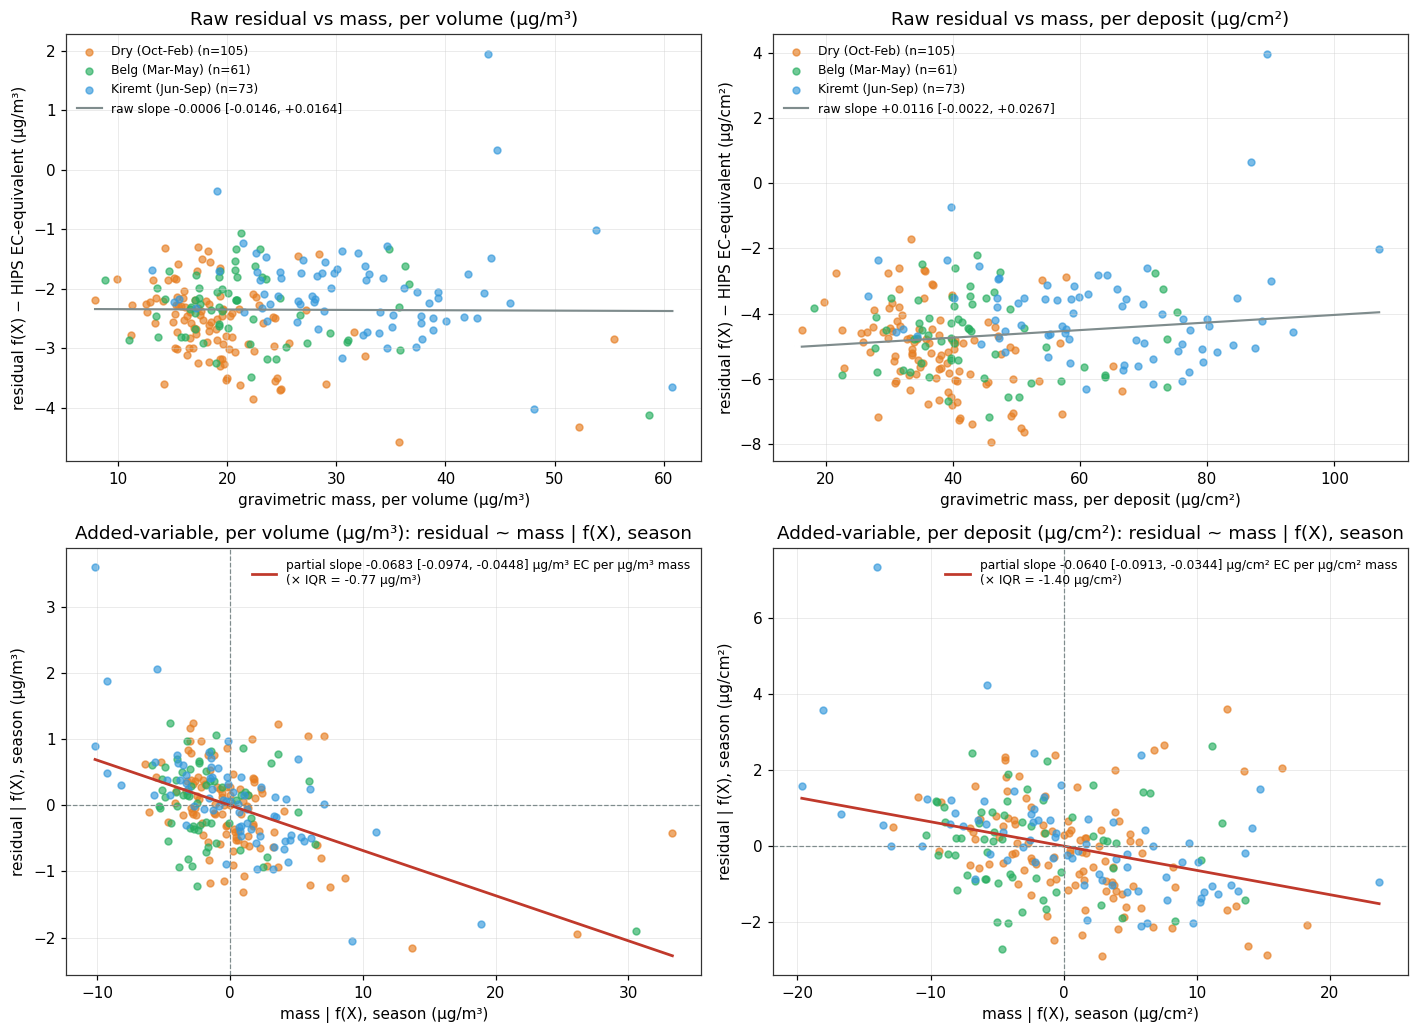

In [7]:
RNG_P1 = np.random.default_rng(20260903)


def ols_coef(design, y, col, rng, n_boot=2000):
    """Coefficient of design[:, col] with a per-filter bootstrap 95% CI."""
    fit = LinearRegression().fit(design, y)
    boots = []
    for _ in range(n_boot):
        take = rng.integers(0, len(y), len(y))
        boots.append(LinearRegression().fit(design[take], y[take]).coef_[col])
    return float(fit.coef_[col]), float(np.quantile(boots, .025)), float(np.quantile(boots, .975))


def added_variable(design_base, x, y):
    """Residualise x and y on the base design (added-variable plot coordinates)."""
    rx = x - LinearRegression().fit(design_base, x).predict(design_base)
    ry = y - LinearRegression().fit(design_base, y).predict(design_base)
    return rx, ry


f_dep = f_x * volume / deposit_area                 # FTIR EC loading, µg/cm²
b_dep = b * volume / deposit_area                   # HIPS EC-equivalent loading, µg/cm²
r_dep = f_dep - b_dep
FRAMINGS = {
    'per volume (µg/m³)': dict(y=r, fx=f_x, m=mass_conc, unit='µg/m³', slope_unit='µg/m³ EC per µg/m³ mass'),
    'per deposit (µg/cm²)': dict(y=r_dep, fx=f_dep, m=mass_area, unit='µg/cm²', slope_unit='µg/cm² EC per µg/cm² mass'),
}
partial_rows = []
for framing, F in FRAMINGS.items():
    base_season = np.column_stack([F['fx'], season_cols])
    base_full = np.column_stack([F['fx'], season_cols, volume, lot_cols])
    iqr = float(np.subtract(*np.percentile(F['m'], [75, 25])))
    for cond_label, base in (('f(X) + season', base_season), ('f(X) + season + volume + lot', base_full)):
        est, lo, hi = ols_coef(np.column_stack([base, F['m']]), F['y'], base.shape[1], RNG_P1)
        partial_rows.append(dict(framing=framing, conditioning=cond_label, slope=est, ci_lo=lo, ci_hi=hi,
                                 slope_unit=F['slope_unit'], slope_x_IQR=est * iqr))
    est, lo, hi = ols_coef(F['m'].reshape(-1, 1), F['y'], 0, RNG_P1)
    partial_rows.append(dict(framing=framing, conditioning='none (raw residual)', slope=est, ci_lo=lo, ci_hi=hi,
                             slope_unit=F['slope_unit'], slope_x_IQR=est * iqr))
partial = pd.DataFrame(partial_rows)
partial.to_csv(OUT / 'addis_residual_vs_mass_partial_slopes.csv', index=False)
display(partial.round(4))

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
for j, (framing, F) in enumerate(FRAMINGS.items()):
    y_, m_, unit = F['y'], F['m'], F['unit']
    ax = axes[0, j]
    for name, color in SEASON_COLORS.items():
        sel = season_name == name
        ax.scatter(m_[sel], y_[sel], s=20, alpha=0.65, color=color, label=f'{name} (n={int(sel.sum())})')
    xs = np.linspace(m_.min(), m_.max(), 10)
    raw = partial[(partial.framing == framing) & partial.conditioning.str.startswith('none')].iloc[0]
    ax.plot(xs, LinearRegression().fit(m_.reshape(-1, 1), y_).predict(xs.reshape(-1, 1)),
            color='#7F8C8D', lw=1.4, label=f'raw slope {raw.slope:+.4f} [{raw.ci_lo:+.4f}, {raw.ci_hi:+.4f}]')
    ax.set(xlabel=f'gravimetric mass, {framing}', ylabel=f'residual f(X) − HIPS EC-equivalent ({unit})',
           title=f'Raw residual vs mass, {framing}')
    ax.legend(frameon=False, fontsize=8)
    ax = axes[1, j]
    base_season = np.column_stack([F['fx'], season_cols])
    rx, ry = added_variable(base_season, m_, y_)
    for name, color in SEASON_COLORS.items():
        sel = season_name == name
        ax.scatter(rx[sel], ry[sel], s=20, alpha=0.65, color=color)
    part = partial[(partial.framing == framing) & (partial.conditioning == 'f(X) + season')].iloc[0]
    xs = np.linspace(rx.min(), rx.max(), 10)
    ax.plot(xs, part.slope * xs, color='#C0392B', lw=1.8,
            label=f'partial slope {part.slope:+.4f} [{part.ci_lo:+.4f}, {part.ci_hi:+.4f}] {part.slope_unit}\n'
                  f'(× IQR = {part.slope_x_IQR:+.2f} {unit})')
    ax.axhline(0, color='#7F8C8D', lw=0.8, ls='--')
    ax.axvline(0, color='#7F8C8D', lw=0.8, ls='--')
    ax.set(xlabel=f'mass | f(X), season ({unit})', ylabel=f'residual | f(X), season ({unit})',
           title=f'Added-variable, {framing}: residual ~ mass | f(X), season')
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS / 'addis_residual_vs_mass.png', bbox_inches='tight')
plt.show()

## Part 2 — does the mass relationship replicate across sites?

### 6. Predictions from the calibration explorer, joined to Fabs, volume and mass

In [8]:
RNG_P2 = np.random.default_rng(20260902)
CONFIGS = {
    'locked 800 + AIRSpec (rule k)': dict(cohort='ocec', cutoff=800, selection_space='raw',
                                          spectra='airspec', mode='site_heldout'),
    'winner 440 + AIRSpec k=8': dict(cohort='ocec', cutoff=440, selection_space='raw',
                                     spectra='airspec', mode='site_heldout', k=8),
}
SITES = {'addis': ('ETAD', 'Addis Ababa'), 'etbi': ('ETBI', 'Bishoftu'), 'chts': ('CHTS', 'Beijing'),
         'indh': ('INDH', 'Delhi'), 'uspa': ('USPA', 'Pasadena')}
CACHE = OUT / 'explorer_predictions.csv'


def explorer_run(body):
    request = Request(f'{EXPLORER.rstrip("/")}/api/run', data=json.dumps(body).encode(),
                      headers={'Content-Type': 'application/json'}, method='POST')
    with urlopen(request, timeout=900) as response:  # noqa: S310
        payload = json.load(response)
    if 'error' in payload:
        raise RuntimeError(payload['error'])
    return payload


def site_reference(site):
    """ExternalFilterId, MediaId, Fabs, Volume_m3, Group, Date in the explorer's evaluation order."""
    if site == 'addis':
        ref = etad_eval[['ExternalFilterId', 'MediaId', 'Fabs', 'SampleVolume_m3', 'SamplingStartDate']].rename(
            columns={'SampleVolume_m3': 'Volume_m3', 'SamplingStartDate': 'Date'}).reset_index(drop=True)
        ref['Group'] = [season_for_month(int(m)) if pd.notna(m) else 'undated' for m in ref['Date'].dt.month]
        return ref
    ref = pd.read_csv(TARGETS_DIR / site / 'reference.csv')
    return ref[['ExternalFilterId', 'MediaId', 'Fabs', 'Volume_m3', 'Group', 'Date']].reset_index(drop=True)


def site_mass(site, ref):
    if site == 'addis':
        m = etad_eval[['ExternalFilterId', 'MassCollectedOnFilter_ug']].rename(
            columns={'MassCollectedOnFilter_ug': 'mass_ug'})
    else:
        code = SITES[site][0]
        cat = pd.read_csv(CATALOG_DIR / code / f'{code}_filters.csv', encoding='utf-8-sig')
        m = cat[['ExternalFilterId', 'MassCollectedOnFilter']].rename(columns={'MassCollectedOnFilter': 'mass_ug'})
    m = m.drop_duplicates('ExternalFilterId')
    area = (hips_lots[hips_lots['Site'].eq(SITES[site][0])].drop_duplicates('FilterId')
            .set_index('FilterId')['DepositArea'])
    out = ref.merge(m, on='ExternalFilterId', how='left', validate='one_to_one')
    out['deposit_area_cm2'] = out['ExternalFilterId'].map(area).fillna(3.53)
    return out


def fetch_predictions():
    rows = []
    for config_name, config in CONFIGS.items():
        for site in SITES:
            payload = explorer_run({**config, 'target': site})
            ref = site_reference(site)
            observed_fabs = np.asarray(payload['eval']['ref'], float)
            predicted = np.asarray(payload['eval']['pred'], float)
            if len(ref) != len(observed_fabs) or not np.allclose(ref['Fabs'], observed_fabs, atol=5e-4):
                raise ValueError(f'{config_name}/{site}: explorer evaluation order does not match the reference table')
            per = site_mass(site, ref)
            per['f_x'] = predicted
            per['config'] = config_name
            per['site'] = site
            per['k'] = payload['k']
            per['heldout_R2'] = payload['heldout']['R2']
            per['extrap_pct'] = payload['target']['extrap_pct']
            per['git_commit'] = payload['provenance']['git_commit']
            per['source_fingerprint'] = payload['provenance']['source_fingerprint']
            rows.append(per)
    return pd.concat(rows, ignore_index=True)


try:
    preds = fetch_predictions()
    preds.to_csv(CACHE, index=False)
    PRED_SOURCE = f'live explorer at {EXPLORER}'
except (URLError, HTTPError, ConnectionError, OSError, RuntimeError, ValueError) as exc:
    if CACHE.exists():
        preds = pd.read_csv(CACHE)
        PRED_SOURCE = f'CACHED explorer predictions ({CACHE}); live explorer unavailable: {exc}'
    else:
        raise RuntimeError(f'calibration explorer unavailable at {EXPLORER} and no cache at {CACHE}: {exc}')
print('predictions source:', PRED_SOURCE)

preds['b'] = preds['Fabs'] / MAC
preds['r'] = preds['f_x'] - preds['b']
preds['mass_conc'] = preds['mass_ug'] / preds['Volume_m3']
preds['mass_area'] = preds['mass_ug'] / preds['deposit_area_cm2']
preds['f_dep'] = preds['f_x'] * preds['Volume_m3'] / preds['deposit_area_cm2']
preds['b_dep'] = preds['b'] * preds['Volume_m3'] / preds['deposit_area_cm2']
preds['r_dep'] = preds['f_dep'] - preds['b_dep']
locked_addis = preds[(preds.site == 'addis') & preds.config.str.startswith('locked')].set_index('MediaId')['f_x']
print(f'explorer locked-800 Addis prediction vs committed ftir_13 f(X): max |Δ| = '
      f'{np.abs(locked_addis.loc[frame["MediaId"]].to_numpy() - f_x).max():.2e} µg/m³')
ADDIS_RANGE = (float(mass_area.min()), float(mass_area.max()))
coverage = (preds.groupby(['config', 'site'])
            .agg(n=('f_x', 'size'), n_mass=('mass_ug', 'count'), k=('k', 'first'),
                 heldout_R2=('heldout_R2', 'first'), extrap_pct=('extrap_pct', 'first'),
                 volume_min=('Volume_m3', 'min'), volume_max=('Volume_m3', 'max'),
                 mass_conc_median=('mass_conc', 'median'), mass_conc_max=('mass_conc', 'max'),
                 mass_area_median=('mass_area', 'median'), mass_area_max=('mass_area', 'max'),
                 n_in_addis_loading_range=('mass_area', lambda s: int(s.between(*ADDIS_RANGE).sum())),
                 corr_mass_fx=('f_x', lambda s: np.corrcoef(s, preds.loc[s.index, 'mass_conc'])[0, 1]))
            .reset_index())
coverage.to_csv(OUT / 'cross_site_coverage.csv', index=False)
print(f'Addis deposit-loading range: {ADDIS_RANGE[0]:.1f}–{ADDIS_RANGE[1]:.1f} µg/cm²')
display(coverage.round(3))

predictions source: live explorer at http://127.0.0.1:5066
explorer locked-800 Addis prediction vs committed ftir_13 f(X): max |Δ| = 4.95e-06 µg/m³
Addis deposit-loading range: 16.3–107.1 µg/cm²


,config,site,n,n_mass,k,heldout_R2,extrap_pct,volume_min,volume_max,mass_conc_median,mass_conc_max,mass_area_median,mass_area_max,n_in_addis_loading_range,corr_mass_fx
0,locked 800 + AIRSpec (rule k),addis,239,239,5,0.904,0.8,2.074,7.358,20.782,60.802,41.218,107.054,239,0.839
1,locked 800 + AIRSpec (rule k),chts,192,192,5,0.904,17.2,2.160,7.272,19.097,129.252,36.742,258.357,143,0.720
2,locked 800 + AIRSpec (rule k),etbi,26,26,5,0.904,23.1,5.316,7.200,17.574,34.833,35.127,71.048,26,0.615
3,locked 800 + AIRSpec (rule k),indh,152,152,5,0.904,16.4,1.602,7.128,52.081,1763.216,53.045,1708.272,122,0.459
4,locked 800 + AIRSpec (rule k),uspa,158,158,5,0.904,0.0,6.912,7.344,6.421,22.152,13.074,44.731,51,0.858
5,winner 440 + AIRSpec k=8,addis,239,239,8,0.924,0.4,2.074,7.358,20.782,60.802,41.218,107.054,239,0.831
6,winner 440 + AIRSpec k=8,chts,192,192,8,0.924,31.8,2.160,7.272,19.097,129.252,36.742,258.357,143,0.404
7,winner 440 + AIRSpec k=8,etbi,26,26,8,0.924,23.1,5.316,7.200,17.574,34.833,35.127,71.048,26,0.376
8,winner 440 + AIRSpec k=8,indh,152,152,8,0.924,27.0,1.602,7.128,52.081,1763.216,53.045,1708.272,122,0.302
9,winner 440 + AIRSpec k=8,uspa,158,158,8,0.924,0.0,6.912,7.344,6.421,22.152,13.074,44.731,51,0.700


### 7. Per-site fits at fixed f(X)

For each site and calibration, in both framings: r ~ mass, r ~ mass + f(X), and the
discriminating fit **Fabs ~ f(X) + mass**. Per volume its mass coefficient is in Mm⁻¹ per
µg/m³; per deposit it is HIPS-EC-equivalent loading ~ FTIR-EC loading + mass loading,
so the coefficient is µg EC-equivalent per µg of mass (× MAC = 10 puts it in the
per-volume column's Mm⁻¹ per µg/m³, since Fabs = MAC·coef·mass/V). Per-filter bootstrap 95% CIs. Robustness columns: season/group dummies added;
the top 1 % of mass removed (Delhi carries one filter at 6030 µg on 3.4 m³ = 1763 µg/m³);
and the fit restricted to the Addis deposit-loading range, because Delhi's loadings run
to ≈1700 µg/cm² where HIPS is in its saturation regime (ftir_37) and no Addis filter
lives.

In [9]:
def fit_rows(df, site_label, config_name):
    df = df.dropna(subset=['mass_ug', 'f_x', 'Fabs'])
    groups = pd.get_dummies(df['Group'].astype(str), drop_first=True).to_numpy(float)
    in_range = df['mass_area'].between(*ADDIS_RANGE).to_numpy()
    rows = []
    for framing, y_col, fx_col, m_col, scale, unit in (
            ('per volume', 'Fabs', 'f_x', 'mass_conc', 1.0, 'Mm⁻¹ per µg/m³'),
            ('per deposit', 'b_dep', 'f_dep', 'mass_area', 1.0, 'µg EC-eq per µg mass')):
        y, fx, m = (df[c].to_numpy(float) for c in (y_col, fx_col, m_col))
        rr = df['r' if framing == 'per volume' else 'r_dep'].to_numpy(float)
        keep99 = m <= np.quantile(m, 0.99)
        row = dict(site=site_label, config=config_name, framing=framing, unit=unit, n=len(df),
                   corr_mass_fx=float(np.corrcoef(m, fx)[0, 1]))
        row['r_slope'], row['r_slope_lo'], row['r_slope_hi'] = ols_coef(m.reshape(-1, 1), rr, 0, RNG_P2)
        row['r_partial'], row['r_partial_lo'], row['r_partial_hi'] = ols_coef(np.column_stack([fx, m]), rr, 1, RNG_P2)
        row['mass_coef'], row['mass_coef_lo'], row['mass_coef_hi'] = ols_coef(np.column_stack([fx, m]), y, 1, RNG_P2)
        row['fx_coef'] = float(LinearRegression().fit(np.column_stack([fx, m]), y).coef_[0])
        if groups.shape[1]:
            row['mass_coef_season'], row['mass_coef_season_lo'], row['mass_coef_season_hi'] = ols_coef(
                np.column_stack([fx, m, groups]), y, 1, RNG_P2)
        else:
            row['mass_coef_season'] = row['mass_coef_season_lo'] = row['mass_coef_season_hi'] = np.nan
        row['mass_coef_trim99'], row['mass_coef_trim99_lo'], row['mass_coef_trim99_hi'] = ols_coef(
            np.column_stack([fx[keep99], m[keep99]]), y[keep99], 1, RNG_P2)
        row['n_trim99'] = int(keep99.sum())
        if in_range.sum() >= 15:
            row['mass_coef_addis_range'], row['mass_coef_addis_range_lo'], row['mass_coef_addis_range_hi'] = ols_coef(
                np.column_stack([fx[in_range], m[in_range]]), y[in_range], 1, RNG_P2)
        else:
            row['mass_coef_addis_range'] = row['mass_coef_addis_range_lo'] = row['mass_coef_addis_range_hi'] = np.nan
        row['n_addis_range'] = int(in_range.sum())
        row['mass_coef_x_IQR'] = row['mass_coef'] * float(np.subtract(*np.percentile(m, [75, 25])))
        rows.append(row)
    return rows


site_rows = []
for config_name in CONFIGS:
    for site, (code, label) in SITES.items():
        site_rows += fit_rows(preds[(preds.site == site) & (preds.config == config_name)], label, config_name)
    for pool_label, members in (('pooled: 4 non-Addis sites', [s for s in SITES if s != 'addis']),
                                ('pooled: all 5 sites', list(SITES))):
        sub = preds[(preds.site.isin(members)) & (preds.config == config_name)].copy()
        sub['Group'] = sub['site']          # site intercepts stand in for the group dummies
        site_rows += fit_rows(sub, pool_label, config_name)
site_fits = pd.DataFrame(site_rows)
site_fits.to_csv(OUT / 'cross_site_mass_slopes.csv', index=False)
SHOW = ['site', 'config', 'n', 'corr_mass_fx', 'r_partial', 'r_partial_lo', 'r_partial_hi',
        'mass_coef', 'mass_coef_lo', 'mass_coef_hi', 'mass_coef_season', 'mass_coef_trim99',
        'mass_coef_addis_range', 'mass_coef_addis_range_lo', 'mass_coef_addis_range_hi', 'n_addis_range', 'mass_coef_x_IQR']
for framing in ('per volume', 'per deposit'):
    unit = site_fits.loc[site_fits.framing == framing, 'unit'].iloc[0]
    print(f'{framing}: mass_coef* = mass coefficient in Fabs ~ f(X) + mass ({unit}); '
          f'r_partial = residual slope on mass at fixed f(X)')
    display(site_fits[site_fits.framing == framing][SHOW].round(4))

per volume: mass_coef* = mass coefficient in Fabs ~ f(X) + mass (Mm⁻¹ per µg/m³); r_partial = residual slope on mass at fixed f(X)


,site,config,n,corr_mass_fx,r_partial,r_partial_lo,r_partial_hi,mass_coef,mass_coef_lo,mass_coef_hi,mass_coef_season,mass_coef_trim99,mass_coef_addis_range,mass_coef_addis_range_lo,mass_coef_addis_range_hi,n_addis_range,mass_coef_x_IQR
0,Addis Ababa,locked 800 + AIRSpec (rule k),239,0.8386,-0.0677,-0.0956,-0.0462,0.6767,0.4575,0.9569,0.6736,0.8325,0.6767,0.4578,0.9547,239,7.5777
2,Bishoftu,locked 800 + AIRSpec (rule k),26,0.6153,-0.0676,-0.1098,-0.0238,0.6756,0.2177,1.0840,NaN,0.6883,0.6756,0.2274,1.1106,26,3.2485
4,Beijing,locked 800 + AIRSpec (rule k),192,0.7197,-0.0195,-0.0270,-0.0136,0.1954,0.1339,0.2666,0.1443,0.2338,0.2605,0.1617,0.3734,143,4.3881
6,Delhi,locked 800 + AIRSpec (rule k),152,0.4588,-0.0100,-0.0400,-0.0096,0.1003,0.0960,0.3959,0.1019,0.3249,0.3136,0.2004,0.4786,122,8.6980
8,Pasadena,locked 800 + AIRSpec (rule k),158,0.8582,-0.0065,-0.0209,0.0054,0.0649,-0.0557,0.2007,0.1235,0.0864,0.0527,-0.0762,0.2536,51,0.3150
10,pooled: 4 non-Addis sites,locked 800 + AIRSpec (rule k),528,0.5733,-0.0106,-0.0324,-0.0100,0.1060,0.0995,0.3243,0.1019,0.2532,0.3511,0.2541,0.4694,342,3.4449
12,pooled: all 5 sites,locked 800 + AIRSpec (rule k),767,0.5795,-0.0101,-0.0310,-0.0095,0.1012,0.0949,0.3149,0.1029,0.2339,0.3025,0.1754,0.4600,581,2.4347
14,Addis Ababa,winner 440 + AIRSpec k=8,239,0.8314,-0.0477,-0.0667,-0.0284,0.4774,0.2884,0.6684,0.4769,0.5567,0.4774,0.2850,0.6701,239,5.3454
16,Bishoftu,winner 440 + AIRSpec k=8,26,0.3764,-0.0642,-0.0907,-0.0327,0.6421,0.3435,0.8939,NaN,0.5667,0.6421,0.3552,0.9170,26,3.0871
18,Beijing,winner 440 + AIRSpec k=8,192,0.4045,-0.0242,-0.0295,-0.0196,0.2416,0.1994,0.2951,0.2273,0.2773,0.2999,0.2407,0.3611,143,5.4257


per deposit: mass_coef* = mass coefficient in Fabs ~ f(X) + mass (µg EC-eq per µg mass); r_partial = residual slope on mass at fixed f(X)


,site,config,n,corr_mass_fx,r_partial,r_partial_lo,r_partial_hi,mass_coef,mass_coef_lo,mass_coef_hi,mass_coef_season,mass_coef_trim99,mass_coef_addis_range,mass_coef_addis_range_lo,mass_coef_addis_range_hi,n_addis_range,mass_coef_x_IQR
1,Addis Ababa,locked 800 + AIRSpec (rule k),239,0.9102,-0.0640,-0.0920,-0.0370,0.0640,0.0374,0.0913,0.0670,0.0676,0.0640,0.0343,0.0908,239,1.4015
3,Bishoftu,locked 800 + AIRSpec (rule k),26,0.6634,-0.0713,-0.1164,-0.0275,0.0713,0.0222,0.1160,NaN,0.0753,0.0713,0.0282,0.1180,26,0.7695
5,Beijing,locked 800 + AIRSpec (rule k),192,0.7246,-0.0192,-0.0265,-0.0132,0.0192,0.0133,0.0268,0.0142,0.0212,0.0258,0.0156,0.0365,143,0.8428
7,Delhi,locked 800 + AIRSpec (rule k),152,0.2787,-0.0098,-0.0313,-0.0091,0.0098,0.0087,0.0301,0.0100,0.0215,0.0319,0.0141,0.0507,122,0.5056
9,Pasadena,locked 800 + AIRSpec (rule k),158,0.8590,-0.0063,-0.0199,0.0053,0.0063,-0.0057,0.0205,0.0122,0.0084,0.0058,-0.0065,0.0262,51,0.0620
11,pooled: 4 non-Addis sites,locked 800 + AIRSpec (rule k),528,0.4203,-0.0110,-0.0266,-0.0101,0.0110,0.0101,0.0269,0.0105,0.0281,0.0332,0.0242,0.0436,342,0.4326
13,pooled: all 5 sites,locked 800 + AIRSpec (rule k),767,0.4309,-0.0092,-0.0291,-0.0080,0.0092,0.0079,0.0286,0.0104,0.0341,0.0444,0.0244,0.0697,581,0.3208
15,Addis Ababa,winner 440 + AIRSpec k=8,239,0.8596,-0.0424,-0.0628,-0.0237,0.0424,0.0219,0.0621,0.0481,0.0447,0.0424,0.0240,0.0616,239,0.9286
17,Bishoftu,winner 440 + AIRSpec k=8,26,0.4403,-0.0655,-0.0933,-0.0367,0.0655,0.0378,0.0927,NaN,0.0591,0.0655,0.0369,0.0936,26,0.7069
19,Beijing,winner 440 + AIRSpec k=8,192,0.4123,-0.0240,-0.0294,-0.0192,0.0240,0.0193,0.0293,0.0226,0.0261,0.0303,0.0242,0.0364,143,1.0529


### 8. Figures — per-site mass coefficients, and the residual-vs-mass grid

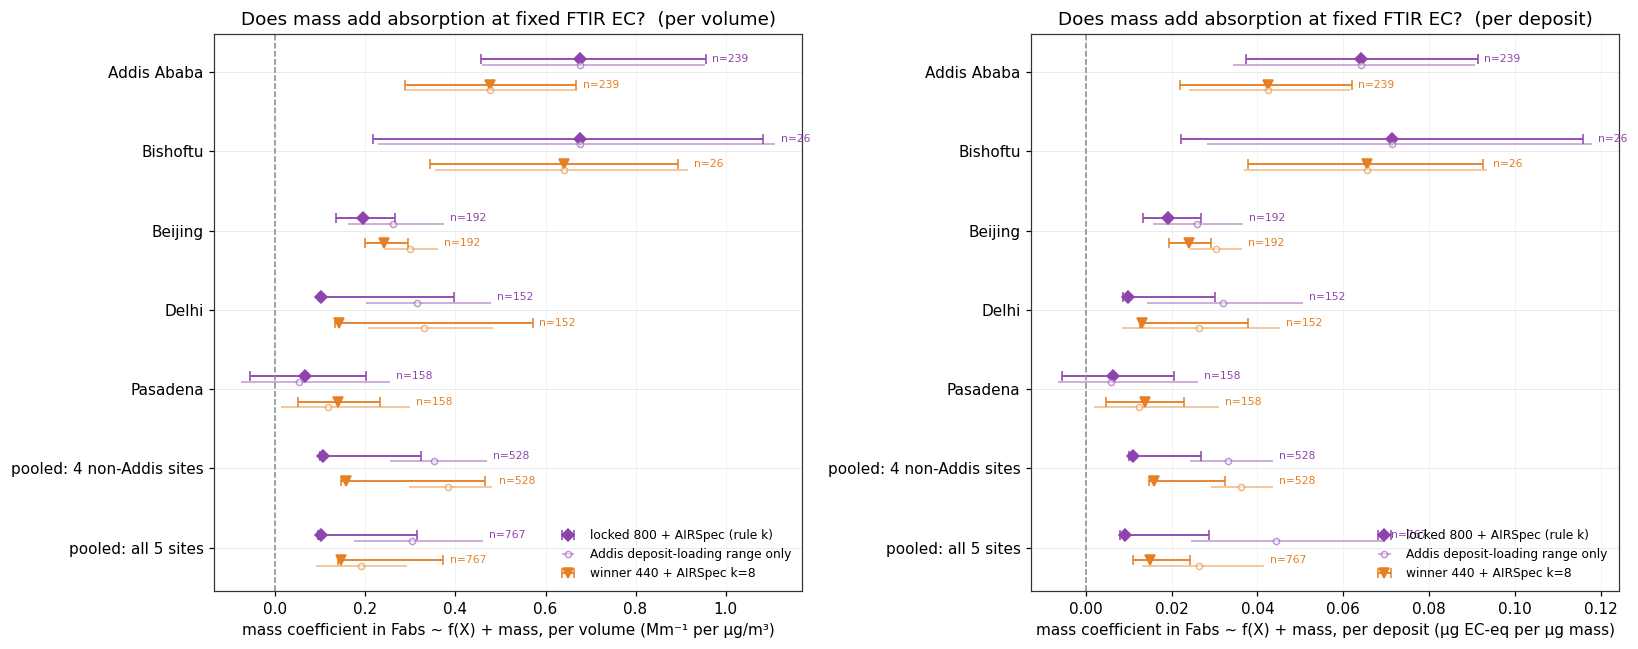

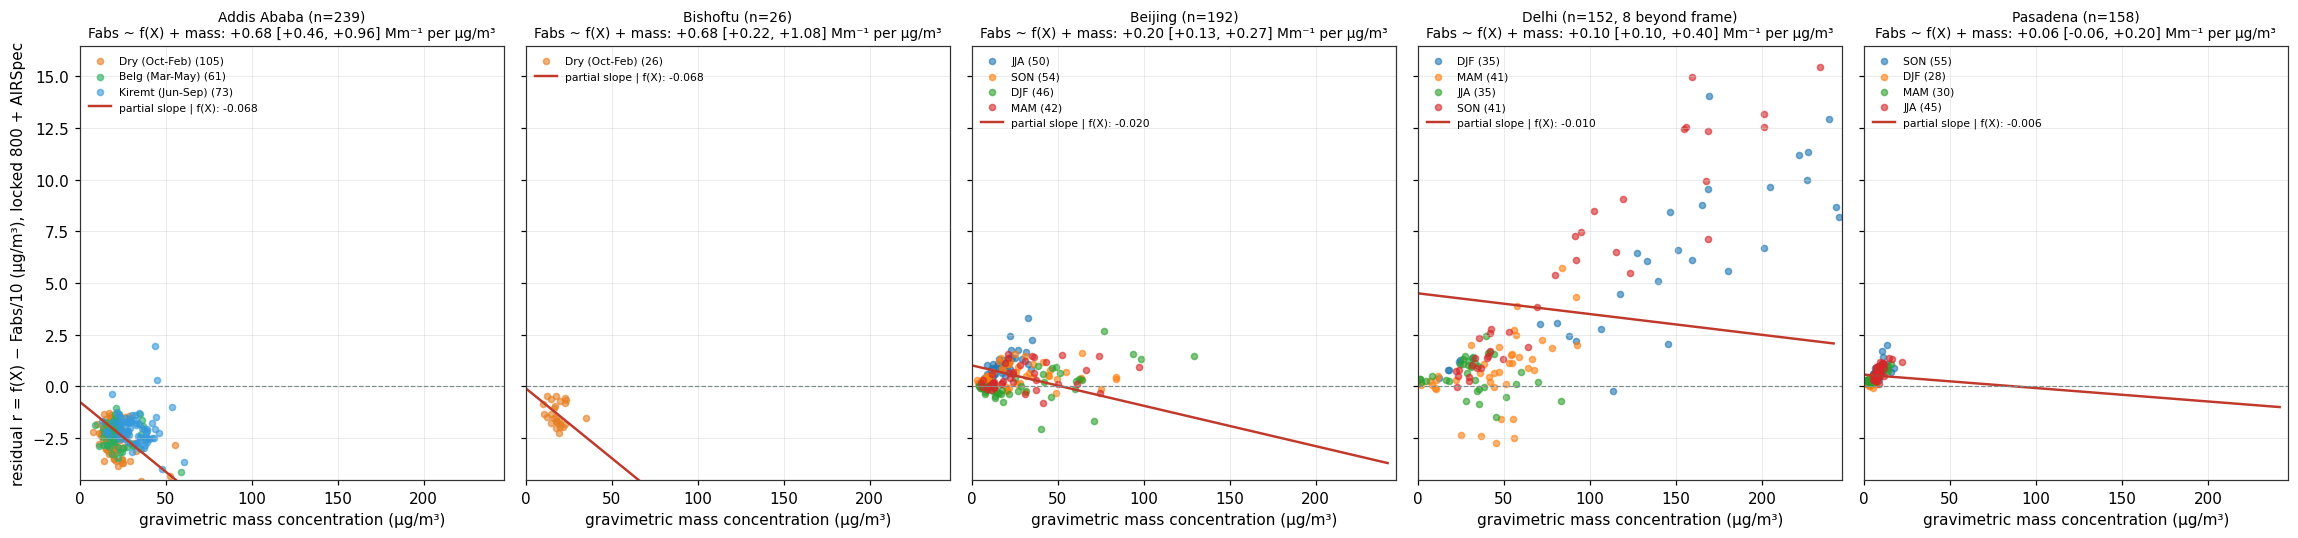

In [10]:
site_order = [SITES[s][1] for s in SITES] + ['pooled: 4 non-Addis sites', 'pooled: all 5 sites']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, framing in zip(axes, ('per volume', 'per deposit')):
    unit = site_fits.loc[site_fits.framing == framing, 'unit'].iloc[0]
    for j, (config_name, color, marker, off) in enumerate(
            (('locked 800 + AIRSpec (rule k)', '#8E44AD', 'D', -0.16), ('winner 440 + AIRSpec k=8', '#E67E22', 'v', 0.16))):
        s = site_fits[(site_fits.framing == framing) & (site_fits.config == config_name)].set_index('site').loc[site_order]
        ys = np.arange(len(site_order)) + off
        ax.errorbar(s.mass_coef, ys, xerr=[s.mass_coef - s.mass_coef_lo, s.mass_coef_hi - s.mass_coef],
                    fmt=marker, color=color, ecolor=color, capsize=3, ms=6, lw=1.2, label=config_name)
        ax.errorbar(s.mass_coef_addis_range, ys + 0.07,
                    xerr=[s.mass_coef_addis_range - s.mass_coef_addis_range_lo,
                          s.mass_coef_addis_range_hi - s.mass_coef_addis_range],
                    fmt='o', mfc='white', mec=color, ecolor=color, alpha=0.55, capsize=0, ms=4, lw=1,
                    label='Addis deposit-loading range only' if j == 0 else None)
        for y_, (site_name, row) in zip(ys, s.iterrows()):
            ax.annotate(f'n={int(row.n)}', (max(row.mass_coef_hi, np.nan_to_num(row.mass_coef_addis_range_hi)), y_),
                        xytext=(4, 0), textcoords='offset points', va='center', fontsize=7, color=color)
    ax.axvline(0, color='#7F8C8D', lw=1, ls='--')
    ax.set(yticks=range(len(site_order)), yticklabels=site_order,
           xlabel=f'mass coefficient in Fabs ~ f(X) + mass, {framing} ({unit})',
           title=f'Does mass add absorption at fixed FTIR EC?  ({framing})')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.tight_layout()
fig.savefig(PLOTS / 'cross_site_mass_slopes.png', bbox_inches='tight')
plt.show()

locked = preds[preds.config.str.startswith('locked')]
x_hi = float(np.nanquantile(locked['mass_conc'], 0.99))
y_lo, y_hi = float(np.nanquantile(locked['r'], 0.005)), float(np.nanquantile(locked['r'], 0.995))
fig, axes = plt.subplots(1, 5, figsize=(21, 5), sharex=True, sharey=True)
for ax, (site, (code, label)) in zip(axes, SITES.items()):
    sub = locked[(locked.site == site)].dropna(subset=['mass_conc'])
    groups = list(dict.fromkeys(sub['Group'].astype(str)))
    palette = SEASON_COLORS if site in ('addis', 'etbi') else dict(zip(groups, plt.cm.tab10.colors))
    for g in groups:
        sel = sub['Group'].astype(str) == g
        ax.scatter(sub.loc[sel, 'mass_conc'], sub.loc[sel, 'r'], s=16, alpha=0.6,
                   color=palette.get(g, '#7F8C8D'), label=f'{g} ({int(sel.sum())})')
    row = site_fits[(site_fits.site == label) & (site_fits.framing == 'per volume')
                    & site_fits.config.str.startswith('locked')].iloc[0]
    m_, r_ = sub['mass_conc'].to_numpy(float), sub['r'].to_numpy(float)
    xs = np.linspace(0, x_hi, 10)
    ax.plot(xs, r_.mean() + row.r_partial * (xs - m_.mean()), color='#C0392B', lw=1.6,
            label=f'partial slope | f(X): {row.r_partial:+.3f}')
    beyond = int((sub['mass_conc'] > x_hi).sum())
    ax.set_title(f'{label} (n={len(sub)}{f", {beyond} beyond frame" if beyond else ""})\n'
                 f'Fabs ~ f(X) + mass: {row.mass_coef:+.2f} [{row.mass_coef_lo:+.2f}, {row.mass_coef_hi:+.2f}] Mm⁻¹ per µg/m³',
                 fontsize=9)
    ax.axhline(0, color='#7F8C8D', lw=0.8, ls='--')
    ax.set_xlabel('gravimetric mass concentration (µg/m³)')
    ax.legend(frameon=False, fontsize=7, loc='upper left')
axes[0].set_ylabel('residual r = f(X) − Fabs/10 (µg/m³), locked 800 + AIRSpec')
axes[0].set(xlim=(0, x_hi * 1.02), ylim=(y_lo - 0.5, y_hi + 0.5))
fig.tight_layout()
fig.savefig(PLOTS / 'cross_site_residual_vs_mass.png', bbox_inches='tight')
plt.show()

## Takeaways

- **ftir_43's "real increment" needed a pairing, and does not pass it alone.** The
  −0.06 µg/m³ spectra gain over metadata has a block-bootstrap interval that spans
  zero on both schemes; only the null test (which asks a weaker question — "could
  no-information spectra do this?") separates it. Quote it as suggestive, not as
  a result.
- **Mass and spectra are complements, not substitutes.** Mass alone: −0.036; spectra
  alone: −0.060; both: −0.161 (0.658 → 0.497), with the paired (d+)−(c+) interval
  clear of zero on both schemes. The residual has a component that is *mass ×
  something the spectra know* — a composition-weighted deposit term. ftir_45's "diffuse,
  not any band height" finding is what that would look like to a linear band model.
- **The mass slope is a cross-site fact with an Ethiopian excess.** Beijing and Delhi
  (inside Addis's loading range) show 0.02–0.03 µg EC-equivalent per µg mass at fixed
  FTIR EC; Addis and Bishoftu show 0.064–0.071. Half of Addis's mass term is therefore
  something HIPS does with any deposit; the other half is Ethiopian. The offset story
  gains a variable: at Addis's median 21 µg/m³ the mass term is ≈ 1.4 µg/m³ of HIPS-EC-
  equivalent, so a "constant offset" that is partly mass-proportional will drift with
  the PM season — the constant-offset product of ftir_43 should be re-read as a
  loading-dependent one.
- **Lot is not the lever** (c vs c0: +0.013 µg/m³, worse), and Pasadena on lot 251 shows
  no mass term, so the filter lot does not explain the Ethiopian excess either.
- **Next discriminating experiments**: (i) HIPS on laboratory non-absorbing deposits
  (ammonium sulfate / kaolinite at 20–100 µg/cm²) — the instrument slope directly;
  (ii) the Addis mass coefficient by PMF source class and by dust fraction
  (ftir_38's 1617/dust attribution) — if it tracks composition, the aerosol reading is
  confirmed and the residual learner has a physical target.

## Limits

- Eight contiguous blocks give eight paired differences; the fold bootstrap is on eight
  numbers and the sign test has no power below 7/8. The block bootstrap is the interval
  to read, and it is wide.
- f(X) and mass are collinear (r = 0.84 at Addis, 0.72 Beijing, 0.86 Pasadena), so the
  split of Fabs between f(X) and mass is a partial regression on correlated regressors;
  the sign and the cross-site ordering are robust to the trim / range / season variants,
  the exact magnitudes are not.
- Bishoftu is 26 filters from one dry season; Pasadena's mass range (IQR ≈ 5 µg/m³) gives
  it almost no leverage — its near-zero coefficient is underpowered, not a clean negative.
- Delhi's deposits run to 1700 µg/cm² where HIPS saturates (ftir_37); its full-range
  coefficient is dominated by that regime and one 6030 µg filter, which is why the
  Addis-range column is the one compared.
- The per-deposit framing assumes DepositArea = 3.53 cm² for every filter (all HIPS rows
  carry that value); any true area variation is invisible here.
- Part 2 predictions were pulled from a private explorer instance (port 5066, started
  because 5058 was down) and cached to `output/tables/ftir46/explorer_predictions.csv`;
  the notebook prints which source it used. The locked-800 Addis predictions match the
  committed ftir_13 f(X) to 5e-6 µg/m³, so Part 1 and Part 2 share the same f(X).